# Cape Cauldron coherent vortices

A coherent Lagrangian vortex boundary is a *closed shear line*, a closed curve
tangent to $\eta^\pm_\lambda$ and so stretched uniformly by $\lambda$ over the
window (Haller & Beron-Vera 2013,
[doi:10.1017/jfm.2013.391](https://doi.org/10.1017/jfm.2013.391)). This
notebook finds them in the Cape Cauldron, the Agulhas-ring corridor south-west
of South Africa, step by step with the elliptic API. The construction and
every parameter are described in the
[API guide](https://lcs-parcels.readthedocs.io/page/api.html), and
`cabo_verde_ftle` explains the Parcels wiring.

In [1]:
# Importing Parcels pulls in the holoviews/bokeh bootstrap and prints an
# alpha-version notice, neither of which belongs on the rendered page.
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from parcels import FieldSet, Particle, ParticleSet, StatusCode
from parcels.convert import copernicusmarine_to_sgrid
from parcels.kernels import AdvectionRK4

from lcs_parcels import (
    NeighborSeedGrid,
    closed_shear_lines,
    elliptic_centres,
    outermost_shear_lines,
    stretch_range,
)

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_47660/2914286310.py:6: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleSet, StatusCode


## Currents

Daily-mean GLORYS12 reanalysis surface currents at 1/12 degree, the local file
that `get_data` writes.

In [2]:
currents = xr.open_dataset("data/cape_cauldron_glorys_daily.nc").load()
currents

<xarray.Dataset> Size: 48MB
Dimensions:    (time: 18, depth: 1, latitude: 385, longitude: 433)
Coordinates:
  * time       (time) datetime64[ns] 144B 2018-05-31 2018-06-01 ... 2018-06-17
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 2kB -52.0 -51.92 -51.83 ... -20.08 -20.0
  * longitude  (longitude) float32 2kB -6.0 -5.917 -5.833 ... 29.83 29.92 30.0
Data variables:
    uo         (time, depth, latitude, longitude) float64 24MB 0.07508 ... nan
    vo         (time, depth, latitude, longitude) float64 24MB 0.05005 ... nan
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

## Parcels v4 field set

In [3]:
sgrid = copernicusmarine_to_sgrid(fields={"U": currents["uo"], "V": currents["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(currents["depth"].values[0])

## Seed grid and window

A box across the Cape Cauldron at 1/25 degree, released on 2018-06-01 and read
at 15 days.

In [4]:
t0 = np.datetime64("2018-06-01")
T = np.timedelta64(15, "D")
lon_axis = np.arange(2.0, 22.0 + 1e-9, 1 / 25)
lat_axis = np.arange(-44.0, -28.0 + 1e-9, 1 / 25)
seed = NeighborSeedGrid.from_axes(lon=lon_axis, lat=lat_axis)
seed

<NeighborSeedGrid 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00>

## Recovery kernel

Particles that leave the domain or hit land are turned into `NaN` in place
(Parcels would otherwise abort the run), so losses propagate as `NaN`
through every diagnostic below. The kernel sets `StatusCode.EndofLoop`
rather than `StatusCode.Delete`, because deleting shrinks the particle
array and breaks the alignment with the seed order.

In [5]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

## Advect forward

In [6]:
lon, lat = seed.to_parcels_pset()
z = np.full(len(lon), z_surface)
pset = ParticleSet(fieldset, pclass=Particle, x=lon, y=lat, z=z, t=t0)
pset.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=T,
    verbose_progress=False,
)
forward = seed.pset_to_flowmap(lon=pset.x, lat=pset.y, t0=t0, t1=t0 + T)
forward

<NeighborFlowMap 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00,
                 t0 2018-06-01T00:00:00, T +15.0 days>

A second run over the first day gives the rotation sense. The polar rotation
angle is defined modulo $2\pi$, so it has to come from a window shorter than
half a turn.

In [7]:
pset_day = ParticleSet(fieldset, pclass=Particle, x=lon, y=lat, z=z, t=t0)
pset_day.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=np.timedelta64(1, "D"),
    verbose_progress=False,
)
first_day = seed.pset_to_flowmap(
    lon=pset_day.x, lat=pset_day.y, t0=t0, t1=t0 + np.timedelta64(1, "D")
)
first_day

<NeighborFlowMap 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00,
                 t0 2018-06-01T00:00:00, T +1.0 days>

## Candidate centres

`elliptic_centres` takes any field. Here it is the Cauchy–Green eigenvalue
ratio $\lambda_2 / \lambda_1$, whose windowed minima mark the vortex cores.

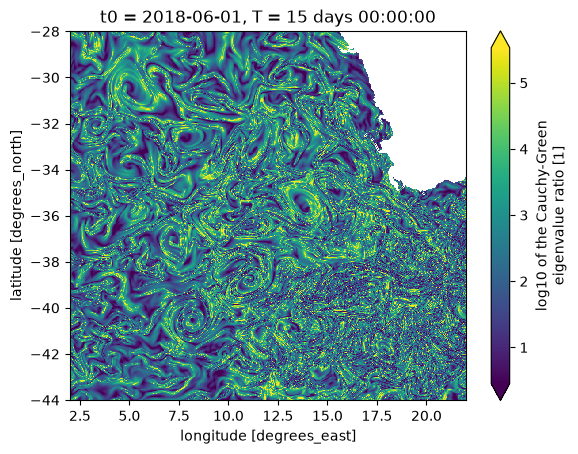

In [8]:
eigen = forward.cg_eigen()
anisotropy = (
    (eigen["lambda"].isel(eig=1, drop=True) / eigen["lambda"].isel(eig=0, drop=True))
    .rename("cg_anisotropy")
    .assign_attrs(
        long_name="Cauchy-Green eigenvalue ratio lambda_2 / lambda_1", units="1"
    )
)
# The ratio spans many decades, so it is drawn as its decimal logarithm.
log_anisotropy = (
    np.log10(anisotropy)
    .rename("log10_cg_anisotropy")
    .assign_attrs(long_name="log10 of the Cauchy-Green eigenvalue ratio", units="1")
)
log_anisotropy.plot.pcolormesh(x="lon_grid", y="lat_grid", robust=True)
plt.show()

In [9]:
centres = elliptic_centres(anisotropy, extremum="min", window_m=100_000.0)
centres

<xarray.Dataset> Size: 6kB
Dimensions:  (centre: 241)
Coordinates:
  * centre   (centre) int64 2kB 0 1 2 3 4 5 6 7 ... 234 235 236 237 238 239 240
Data variables:
    lon      (centre) float64 2kB 2.68 2.72 2.88 2.92 ... 21.28 21.32 21.36
    lat      (centre) float64 2kB -34.96 -41.52 -38.96 ... -41.44 -37.04 -42.48
Attributes:
    extremum:          min
    edge_m:            50000.0
    edge_cells_i:      14
    edge_cells_j:      12
    window_m:          100000.0
    window_cells_i:    27
    window_cells_j:    21
    grid_spacing_i_m:  3598.343413748942
    grid_spacing_j_m:  4447.797065782255

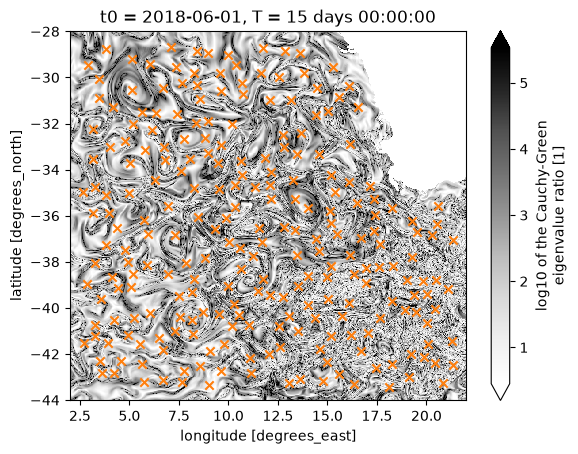

In [10]:
_, ax = plt.subplots()
log_anisotropy.plot.pcolormesh(
    x="lon_grid", y="lat_grid", ax=ax, cmap="Greys", robust=True
)
ax.scatter(centres["lon"], centres["lat"], marker="x", color="tab:orange")
plt.show()

## The scan over $\lambda$

`stretch_range` is the default scan, log-symmetric about 1 from about 0.68 to
1.48 in steps of 0.03 in $\ln \lambda$.

In [11]:
stretches = stretch_range(stretch_max=1.5, step=0.03)
stretches

array([0.67705687, 0.69767633, 0.71892373, 0.74081822, 0.76337949,
       0.78662786, 0.81058425, 0.83527021, 0.86070798, 0.88692044,
       0.91393119, 0.94176453, 0.97044553, 1.        , 1.03045453,
       1.06183655, 1.09417428, 1.12749685, 1.16183424, 1.19721736,
       1.23367806, 1.27124915, 1.30996445, 1.34985881, 1.39096813,
       1.43332941, 1.47698079])

## Closed shear lines

Every closed orbit at every centre, stretching factor and branch, from two
sections running 150 km due east and due west of each centre.

In [12]:
orbits = closed_shear_lines(
    forward,
    centre_lon=centres["lon"],
    centre_lat=centres["lat"],
    stretches=stretches,
    max_radius_m=150_000.0,
)
orbits

<xarray.Dataset> Size: 882kB
Dimensions:     (orbit: 192, point: 282)
Coordinates:
  * orbit       (orbit) int64 2kB 0 1 2 3 4 5 6 ... 185 186 187 188 189 190 191
  * point       (point) int64 2kB 0 1 2 3 4 5 6 ... 275 276 277 278 279 280 281
Data variables:
    lon         (orbit, point) float64 433kB 5.668 5.664 5.659 ... nan nan nan
    lat         (orbit, point) float64 433kB -30.56 -30.54 -30.53 ... nan nan
    centre      (orbit) int64 2kB 36 36 36 30 30 30 ... 163 240 240 240 240 240
    centre_lon  (orbit) float64 2kB 5.12 5.12 5.12 4.76 ... 21.36 21.36 21.36
    centre_lat  (orbit) float64 2kB -30.56 -30.56 -30.56 ... -42.48 -42.48
    stretch     (orbit) float64 2kB 1.0 0.9704 1.0 ... 0.6977 0.7189 0.7634
    branch      (orbit) int64 2kB 1 1 1 -1 -1 -1 -1 -1 ... -1 -1 -1 -1 -1 -1 -1
    area_m2     (orbit) float64 2kB 8.782e+09 1.26e+10 ... 6.481e+08 1.033e+09
    radius_m    (orbit) float64 2kB 5.287e+04 6.333e+04 ... 1.436e+04 1.813e+04
    residual_m  (orbit) float64 2kB 45.92 142.3 58.86 ... 271.6 298.1 1.634e+03
Attributes:
    stretch_min:       0.6770568744981647
    stretch_max:       1.4769807938826427
    n_stretch:         27
    max_radius_m:      150000.0
    launch_spacing_m:  3598.343413748942
    step_m:            1799.171706874471
    closure_tol_m:     1799.171706874471
    n_centres:         241
    n_never_returned:  25573

Each orbit's equivalent radius against the $\lambda$ it closed at, all centres
together.

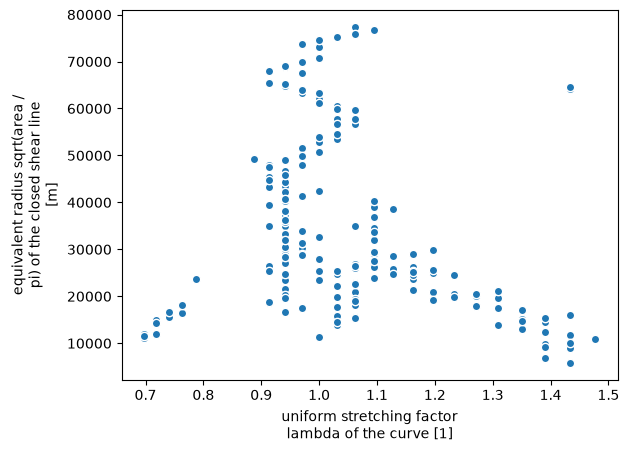

In [13]:
orbits.plot.scatter(x="stretch", y="radius_m")
plt.show()

## The outermost boundary per vortex

`outermost_shear_lines` keeps the largest orbit per centre and merges centres
that one boundary encloses. With the first day's polar rotation it adds
`rotation_sense`, counter-clockwise positive. South of the equator a clockwise
eddy is cyclonic.

In [14]:
eddies = outermost_shear_lines(orbits, rotation=first_day.polar_rotation())
eddies

<xarray.Dataset> Size: 58kB
Dimensions:         (eddy: 12, point: 282)
Coordinates:
  * eddy            (eddy) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    orbit_index     (eddy) int64 96B 64 101 117 33 8 176 95 128 100 186 191 166
  * point           (point) int64 2kB 0 1 2 3 4 5 6 ... 276 277 278 279 280 281
Data variables: (12/13)
    lon             (eddy, point) float64 27kB 5.909 5.901 5.893 ... nan nan nan
    lat             (eddy, point) float64 27kB -30.56 -30.55 -30.53 ... nan nan
    centre          (eddy) int64 96B 36 72 73 34 30 141 50 76 63 163 240 84
    centre_lon      (eddy) float64 96B 5.12 7.76 7.76 5.04 ... 14.0 21.36 8.4
    centre_lat      (eddy) float64 96B -30.56 -42.72 -32.68 ... -42.48 -28.84
    stretch         (eddy) float64 96B 1.062 1.433 0.8869 ... 0.7866 0.7634 1.0
    ...              ...
    area_m2         (eddy) float64 96B 1.882e+10 1.312e+10 ... 3.959e+08
    radius_m        (eddy) float64 96B 7.74e+04 6.463e+04 ... 1.123e+04
    residual_m      (eddy) float64 96B 124.9 1.527e+03 ... 1.634e+03 1.474e+03
    centroid_lon    (eddy) float64 96B 5.199 7.107 7.938 ... 13.93 21.35 8.338
    centroid_lat    (eddy) float64 96B -30.59 -42.62 -32.68 ... -42.6 -28.94
    rotation_sense  (eddy) int64 96B 1 -1 1 -1 -1 -1 1 1 1 -1 -1 1
Attributes:
    stretch_min:            0.6770568744981647
    stretch_max:            1.4769807938826427
    n_stretch:              27
    max_radius_m:           150000.0
    launch_spacing_m:       3598.343413748942
    step_m:                 1799.171706874471
    closure_tol_m:          1799.171706874471
    n_centres:              241
    n_never_returned:       25573
    n_orbits_in:            192
    n_centres_with_orbits:  13

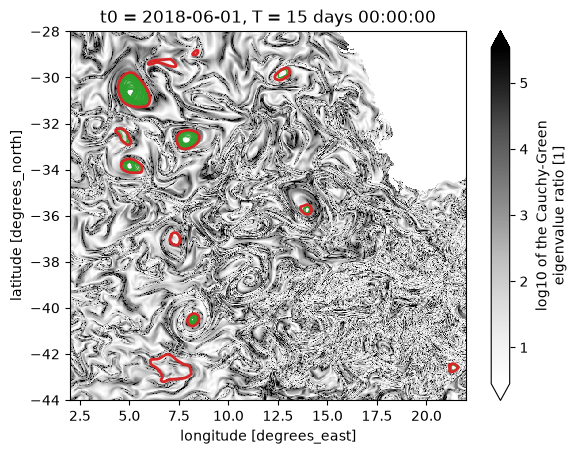

In [15]:
_, ax = plt.subplots()
log_anisotropy.plot.pcolormesh(
    x="lon_grid", y="lat_grid", ax=ax, cmap="Greys", robust=True
)
ax.plot(orbits["lon"].T, orbits["lat"].T, color="tab:green", lw=0.5)
ax.plot(eddies["lon"].T, eddies["lat"].T, color="tab:red", lw=2.0)
plt.show()

## The polar rotation angle

The rotation over the first day, which $C$ discards, with the boundaries on
top.

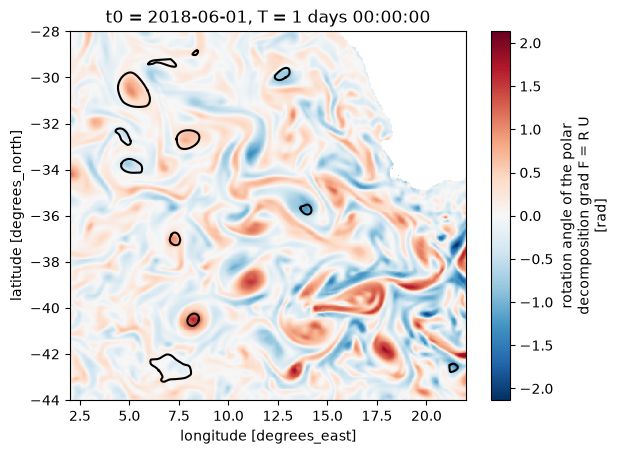

In [16]:
_, ax = plt.subplots()
first_day.polar_rotation().plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax)
ax.plot(eddies["lon"].T, eddies["lat"].T, color="black", lw=1.5)
plt.show()

## The boundaries at the end of the window

A boundary is a material curve, so `forward.image` carries it to $t_1$
through the flow map already computed, with no second Parcels run.

In [17]:
evolved = forward.image(lon_0=eddies["lon"], lat_0=eddies["lat"])

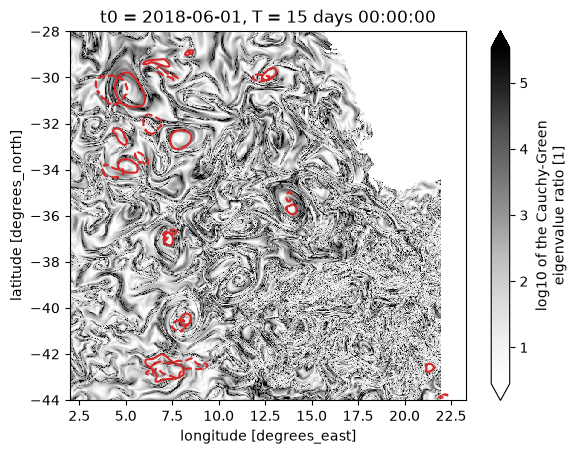

In [18]:
_, ax = plt.subplots()
log_anisotropy.plot.pcolormesh(
    x="lon_grid", y="lat_grid", ax=ax, cmap="Greys", robust=True
)
ax.plot(eddies["lon"].T, eddies["lat"].T, color="tab:red", lw=1.5)
ax.plot(evolved["lon"].T, evolved["lat"].T, color="tab:red", lw=1.5, ls="--")
plt.show()

## In one call

`elliptic_lcs` runs the centres, the search and the selection at the package
defaults. It has only the 15-day flow map, so its boundaries carry no
rotation sense.

In [19]:
forward.elliptic_lcs()

<xarray.Dataset> Size: 5MB
Dimensions:        (eddy: 12, point: 282, i: 501, j: 401)
Coordinates:
  * eddy           (eddy) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    orbit_index    (eddy) int64 96B 64 101 117 33 8 176 95 128 100 186 191 166
  * point          (point) int64 2kB 0 1 2 3 4 5 6 ... 276 277 278 279 280 281
  * i              (i) int64 4kB 0 1 2 3 4 5 6 7 ... 494 495 496 497 498 499 500
  * j              (j) int64 3kB 0 1 2 3 4 5 6 7 ... 394 395 396 397 398 399 400
    lon_grid       (i, j) float64 2MB 2.0 2.0 2.0 2.0 ... 22.0 22.0 22.0 22.0
    lat_grid       (i, j) float64 2MB -44.0 -43.96 -43.92 ... -28.04 -28.0
    t0             datetime64[s] 8B 2018-06-01
    T              timedelta64[s] 8B 15 days
Data variables: (12/13)
    lon            (eddy, point) float64 27kB 5.909 5.901 5.893 ... nan nan nan
    lat            (eddy, point) float64 27kB -30.56 -30.55 -30.53 ... nan nan
    centre         (eddy) int64 96B 36 72 73 34 30 141 50 76 63 163 240 84
    centre_lon     (eddy) float64 96B 5.12 7.76 7.76 5.04 ... 14.0 21.36 8.4
    centre_lat     (eddy) float64 96B -30.56 -42.72 -32.68 ... -42.48 -28.84
    stretch        (eddy) float64 96B 1.062 1.433 0.8869 ... 0.7866 0.7634 1.0
    ...             ...
    area_m2        (eddy) float64 96B 1.882e+10 1.312e+10 ... 3.959e+08
    radius_m       (eddy) float64 96B 7.74e+04 6.463e+04 ... 1.813e+04 1.123e+04
    residual_m     (eddy) float64 96B 124.9 1.527e+03 ... 1.634e+03 1.474e+03
    centroid_lon   (eddy) float64 96B 5.199 7.107 7.938 ... 13.93 21.35 8.338
    centroid_lat   (eddy) float64 96B -30.59 -42.62 -32.68 ... -42.6 -28.94
    cg_anisotropy  (i, j) float64 2MB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/20)
    stretch_min:               0.6770568744981647
    stretch_max:               1.4769807938826427
    n_stretch:                 27
    max_radius_m:              150000.0
    launch_spacing_m:          3598.343413748942
    step_m:                    1799.171706874471
    ...                        ...
    centres_edge_cells_j:      12
    centres_window_m:          100000.0
    centres_window_cells_i:    27
    centres_window_cells_j:    21
    centres_grid_spacing_i_m:  3598.343413748942
    centres_grid_spacing_j_m:  4447.797065782255

## Outcome

`elliptic_centres` picks 241 candidate centres, and `closed_shear_lines`
closes 192 orbits at 13 of them. `outermost_shear_lines` keeps 12 boundaries,
six turning counter-clockwise over the first day and six clockwise.
`elliptic_lcs` returns the same 12 boundaries in one call.